# FMU Simulation

## FMPy

Example of a simple 1-DOF pendulum.

In [ ]:
import numpy as np
from fmpy import *
from fmpy.fmi2 import FMU2Slave

filename = "Pendulum.fmu"
md = read_model_description(filename)
vars = md.modelVariables
vars = {var.name: var for var in vars}
pendulum = FMU2Slave(
    instanceName="Penudulum",
    guid=md.guid,
    unzipDirectory=extract(filename),
    modelIdentifier=md.coSimulation.modelIdentifier,
)
pendulum.instantiate()
pendulum.setupExperiment(startTime=0.0)
pendulum.enterInitializationMode()
pendulum.setReal([vars["m"].valueReference], [1.0])
pendulum.setReal([vars["L"].valueReference], [1.0])
pendulum.setReal([vars["q0"].valueReference], [np.pi / 4])
pendulum.exitInitializationMode()
q_state_0 = pendulum.getReal([vars["q"].valueReference])[0]
pendulum.setReal([vars["torque"].valueReference], [100.0])

t_start = 0.0
t_end = 2.0
dt = 0.01
n_steps = int((t_end - t_start) / dt)
time = t_start
for step in range(n_steps):
    pendulum.doStep(currentCommunicationPoint=time, communicationStepSize=dt)
    time += dt

q_state = pendulum.getReal([vars["q"].valueReference])[0]

print(f"q_state changed from {q_state_0} to {q_state}")

TypeError: simulate_fmu() got an unexpected keyword argument 'stopTime'

## PyFMI

In [12]:
from pyfmi import load_fmu

In [16]:
model = load_fmu("Pendulum.fmu")
res = model.simulate(final_time=10)

time_pyfmi = res["time"]
theta_pyfmi = res["q"]
omega_pyfmi = res["omega"]

Simulation interval    : 0.0 - 10.0 seconds.
Elapsed simulation time: 0.028786503000446828 seconds.


In [17]:
model.simulate?

Signature:
model.simulate(
    start_time='Default',
    final_time='Default',
    input=(),
    algorithm='FMICSAlg',
    options={},
)
Docstring:
Compact function for model simulation.

The simulation method depends on which algorithm is used, this can be
set with the function argument 'algorithm'. Options for the algorithm
are passed as option classes or as pure dicts. See
FMUModel.simulate_options for more details.

The default algorithm for this function is FMICSAlg.

Parameters::

    start_time --
        Start time for the simulation.
        Default: Start time defined in the default experiment from
                the ModelDescription file.

    final_time --
        Final time for the simulation.
        Default: Stop time defined in the default experiment from
                the ModelDescription file.

    input --
        Input signal for the simulation. The input should be a 2-tuple
        consisting of first the names of the input variable(s) and then
        the data 

## Comparison

NameError: name 'time_fmpy' is not defined

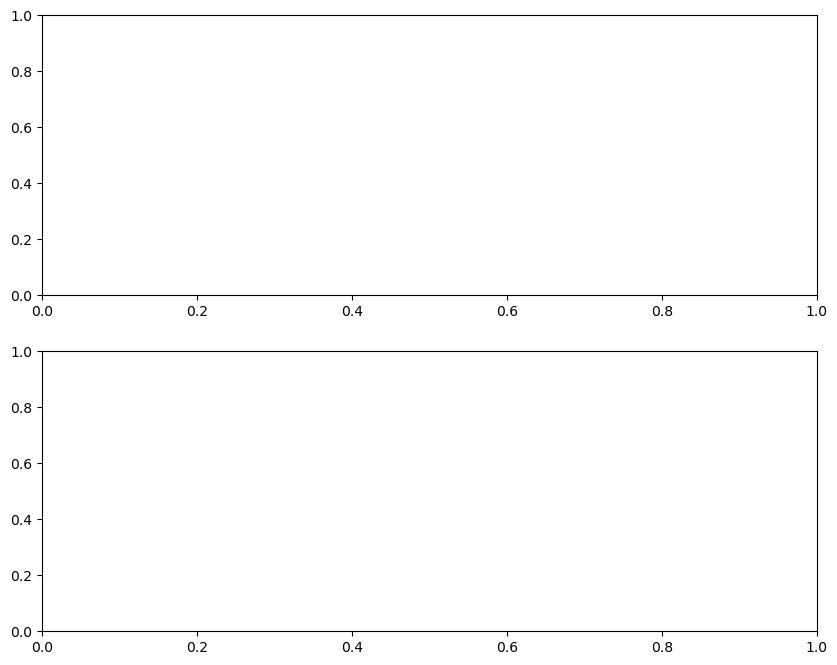

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].plot(time_fmpy, theta_fmpy, label="FMPy")
ax[0].plot(time_pyfmi, theta_pyfmi, label="PyFMI")
ax[0].set_title("Pendulum Angle Comparison")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Angle (rad)")
ax[0].legend()
ax[0].grid()
ax[1].plot(time_fmpy, omega_fmpy, label="FMPy")
ax[1].plot(time_pyfmi, omega_pyfmi, label="PyFMI")
ax[1].set_title("Pendulum Angular Velocity Comparison")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Angular Velocity (rad/s)")
ax[1].legend()
ax[1].grid()
plt.tight_layout()
plt.show()